# Exploración del Dataset

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pyarrow

In [22]:
# Cargamos los datos de la tabla de galaxias centrales
data_centrales = pl.read_csv('data/tracks_centrales_snap28.csv')

# Cargamos los datos de las fusines
data_fusiones = pl.read_csv('data/historial_merger_centrales_snap28.csv')

In [23]:
# Información hisórica del desarrollo de las galaxias centrales
data_centrales

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361


In [24]:
# Le agregamos una columna de tiempo a la tabla de galaxias centrales usando el diccionario de snaps a tiempos
# Diccionario para mapear los snaps a tiempos aproximados en Gyr
snap_to_time = {12:11.68, 13:11.17, 14:10.87, 15:10.54, 16:10.05, 17:9.49, 18:8.86, 19: 7.96,
                20: 7.35, 21:6.69, 22: 5.98, 23: 5.22, 24: 4.12, 25: 3.24, 26: 2.32, 27: 1.35, 28: 0}
map_df = pl.DataFrame({
    "SnapNum": list(snap_to_time.keys()),
    "LookbackTime(Gyr)": list(snap_to_time.values())
})

data_centrales = data_centrales.join(map_df, on="SnapNum", how="left")

In [25]:
data_centrales

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr)
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377,11.68
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377,11.17
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377,10.87
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377,10.54
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377,10.05
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32


In [26]:
# Historial de fusiones de las galaxias centrales
data_fusiones

GalaxyID,Snapshot,Lm
i64,i64,f64
8646377,3,1.0
8646377,4,1.0
8646377,5,1.0
8646377,6,1.0
8646377,7,1.0
…,…,…
21986361,24,1.001543
21986361,25,1.000458
21986361,26,1.041736


In [27]:
# Unimos las tablas para obtener una visión completa de la evolución de las galaxias centrales
new_data = data_centrales.join(data_fusiones, left_on=['RootGalaxyID','SnapNum'], right_on=['GalaxyID','Snapshot'], how='left')

new_data

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
8646393,12,3.0165045,1.8160373e8,8.9158e11,-82.79168,-55.60781,-12.126945,9.0397677e8,0.001334,0.7472645,12797.512,3.7069e12,2.2132e11,-2.7809e13,-47.896557,-75.066986,-49.20585,149624.95,1.0145e-10,8646393,8646377,11.68,1.020797
8646392,13,2.4784133,4.0484758e8,1.6541e12,-27.682028,55.63432,90.33163,1.0362e9,0.002073,0.745057,11154.858,3.3986e12,2.2240e11,-3.7311e13,-28.94864,177.06952,169.04736,149628.08,2.2226e-9,8646392,8646377,11.17,1.208551
8646391,14,2.237037,6.7043725e8,4.5140e12,-441.0218,-108.29286,311.47806,2.2858e9,0.002123,0.7448175,11240.432,1.2060e13,4.9555e11,-1.1021e14,-98.34161,193.81024,268.26166,149650.48,7.4560e-9,8646391,8646377,10.87,1.002513
8646390,15,2.0124102,1.0876e9,6.8919e12,-590.81024,-142.63943,503.46362,2.9391e9,0.003144,0.7411371,12233.35,2.1326e13,6.9291e11,-1.5328e14,-486.67294,-134.645,331.67664,149653.77,7.1106e-9,8646390,8646377,10.54,1.0
8646389,16,1.7369658,1.7818e9,8.2777e12,-443.32837,-363.82037,186.82681,3.5689e9,0.004233,0.7362861,9807.323,1.7867e13,6.7435e11,-2.1800e14,-560.2389,-350.9041,29.797092,298193.6,2.2962e-8,8646389,8646377,10.05,1.004163
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12,1.001543
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24,1.000458
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32,1.041736


In [28]:
# Trabajamos con galaxias que no hayan tenido en su historia fusiones mayores a un Lm mayor a 2.5.
# Me guardo el ID de las galaxias que cumplen esta condición para luego filtrar el dataset original

list_id = new_data.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')
#new_data.group_by('RootGalaxyID').agg(pl.max('Lm').alias('max')).filter(pl.col('max') < 2.5).select('RootGalaxyID')

mask_id = (pl.col('RootGalaxyID').is_in(list_id['RootGalaxyID']))

# Filtramos el dataset original para quedarnos solo con las galaxias que cumplen la condición
filtered_data = new_data.filter(mask_id)

/tmp/ipykernel_56562/1865654661.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  filtered_data = new_data.filter(mask_id)


In [29]:
# Calculamos variables adicionales para el análisis


filtered_data = filtered_data.with_columns(
    # Logaritmos
    pl.col('Stars_Mass').log10().alias('Log(Stars_Mass)'),
    pl.col('BlackHoleMass').log10().alias('Log(BlackHoleMass)'),
    
    # Norma de Stars_Spin (usando una expresión más limpia)
    (pl.col('Stars_Spin_x')**2 + pl.col('Stars_Spin_y')**2 + pl.col('Stars_Spin_z')**2)
    .sqrt().alias('Stars_Spin_Total'),
    
    # Norma de SF_Spin
    (pl.col('SF_Spin_x')**2 + pl.col('SF_Spin_y')**2 + pl.col('SF_Spin_z')**2)
    .sqrt().alias('SF_Spin_Total'),
    
    # Norma del Spin de gas SF y Stars
    ((pl.col('SF_Spin_x')+pl.col('Stars_Spin_x'))**2 + (pl.col('SF_Spin_y')+pl.col('Stars_Spin_y'))**2 + (pl.col('SF_Spin_z')+pl.col('Stars_Spin_z'))**2)
    .sqrt().alias('Total_Spin'),
    
    # Calculo de metalicidad.
    (12 + pl.col('SF_Oxygen').log10() - pl.col('SF_Hydrogen').log10()-np.log10(16)).alias('12+log(O/H)')
)

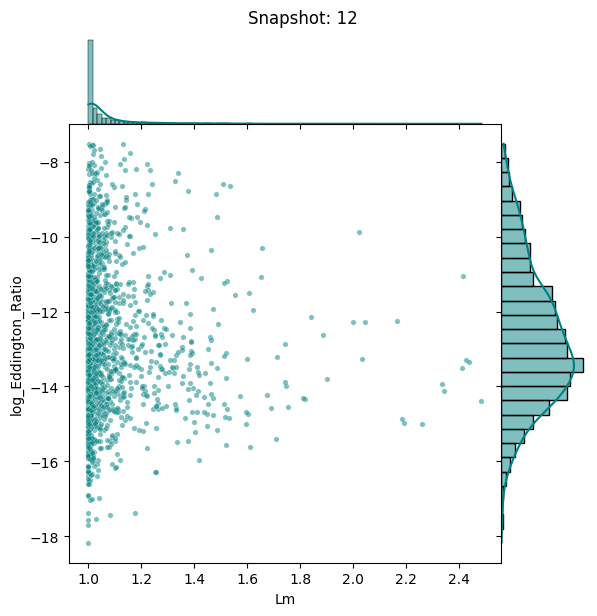

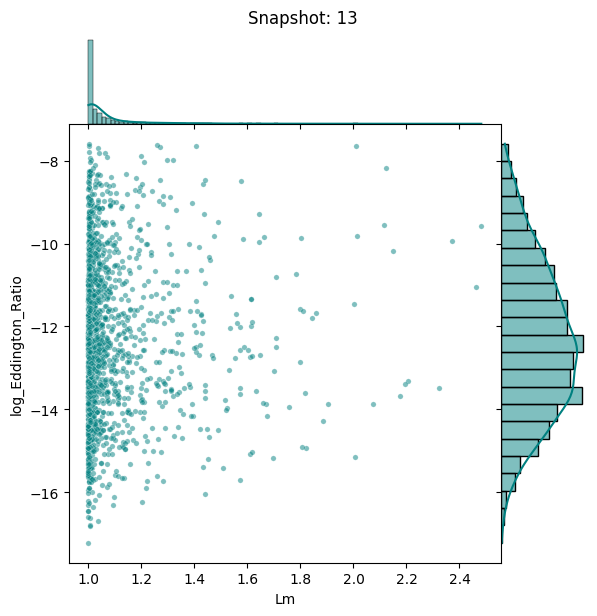

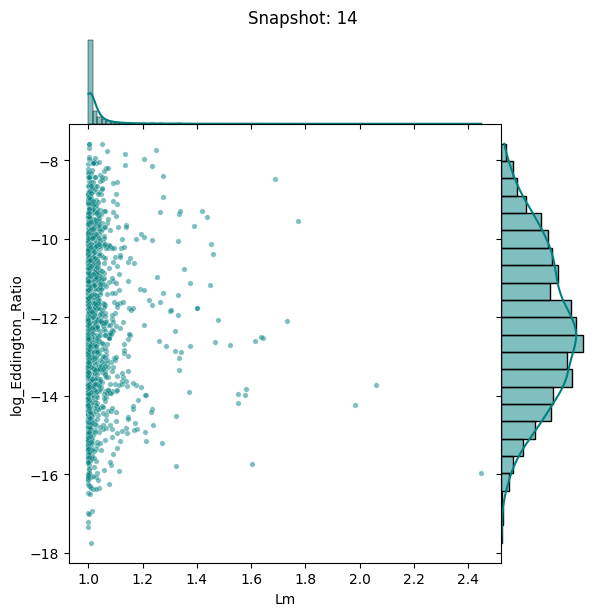

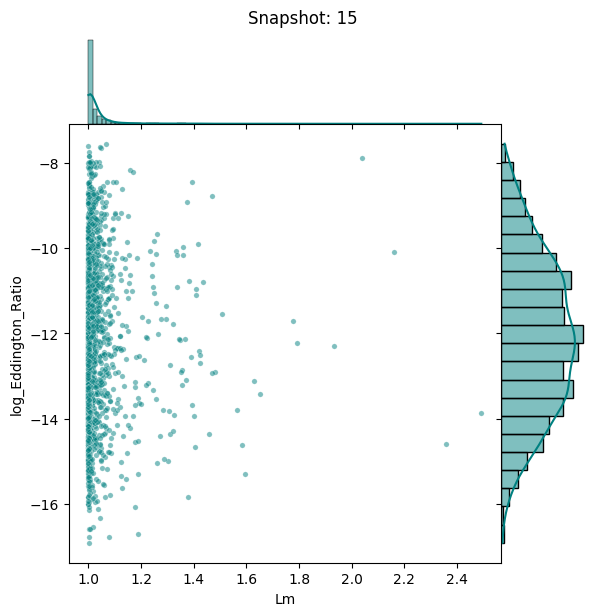

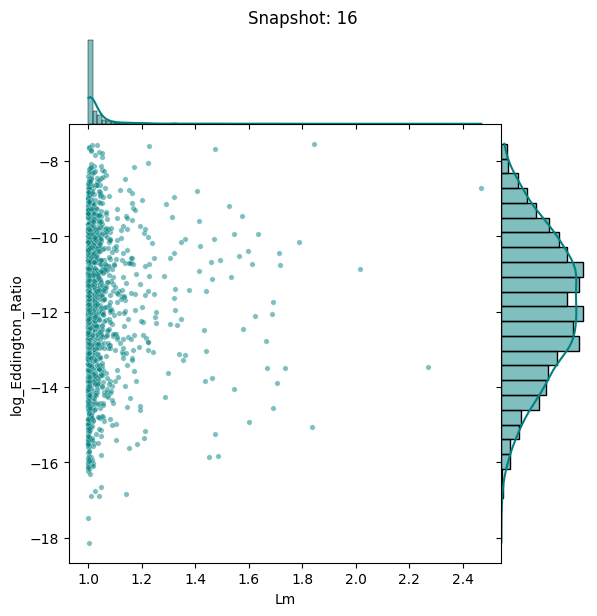

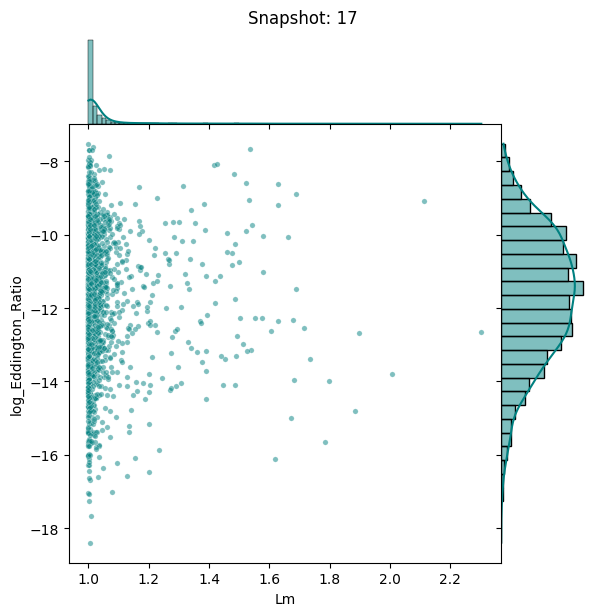

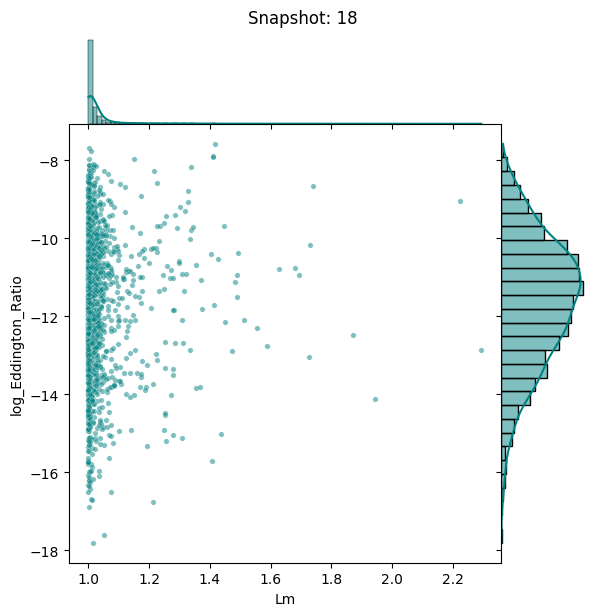

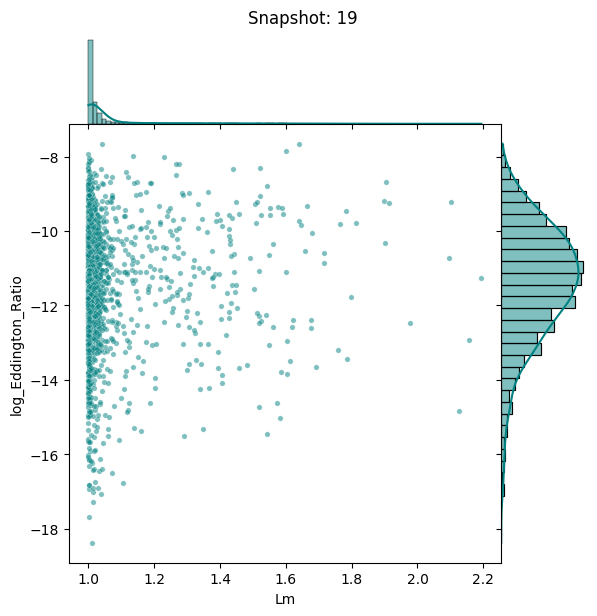

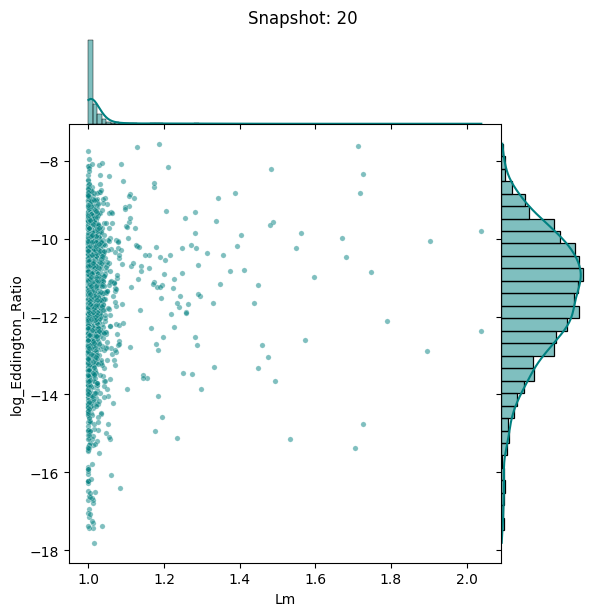

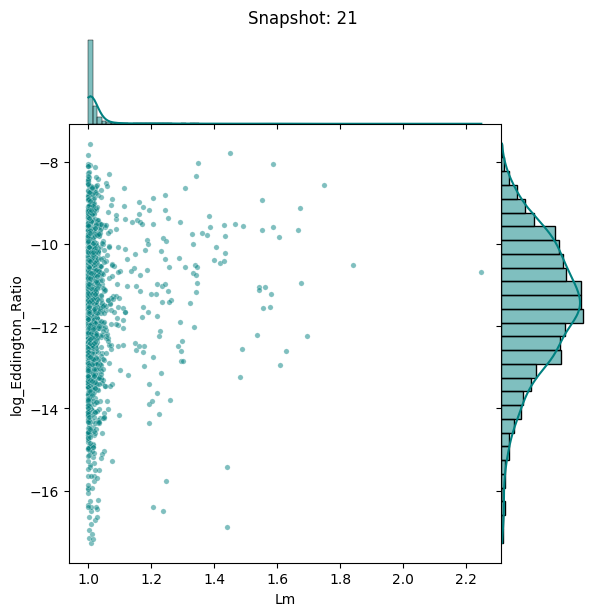

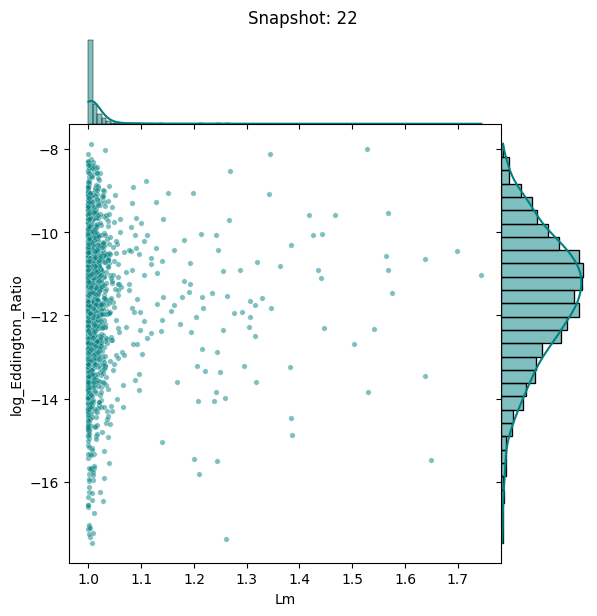

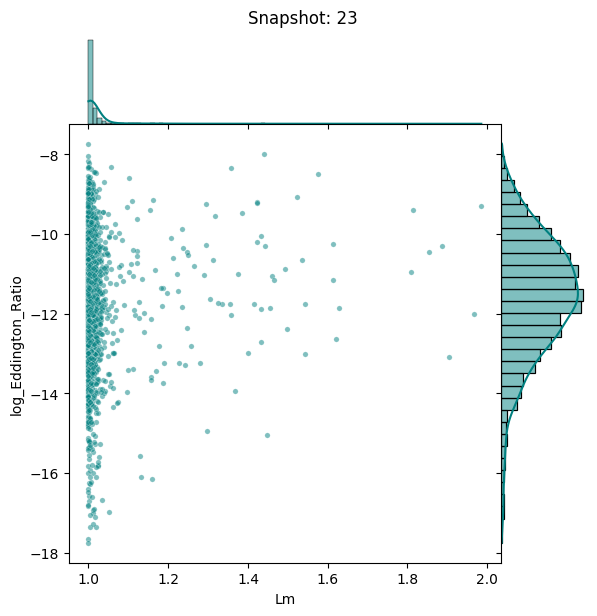

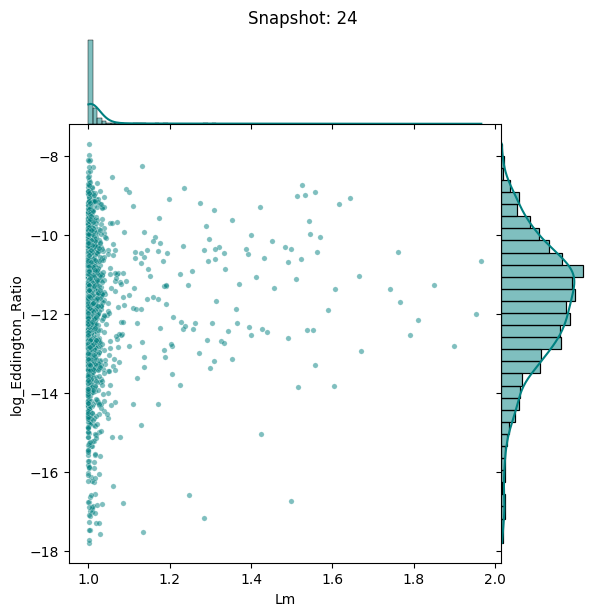

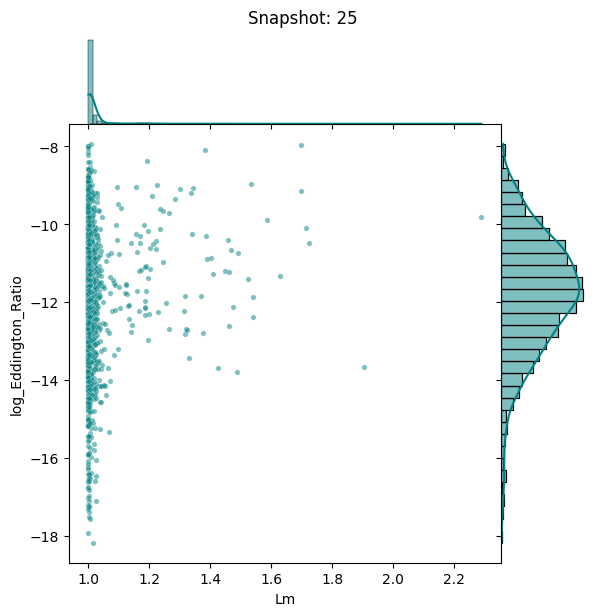

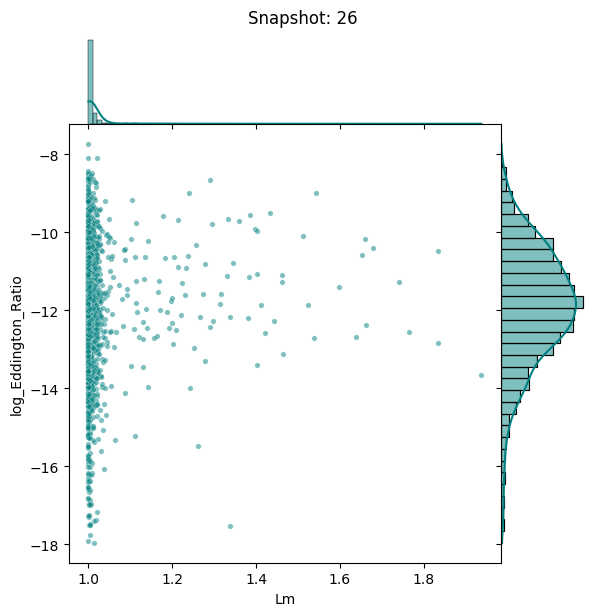

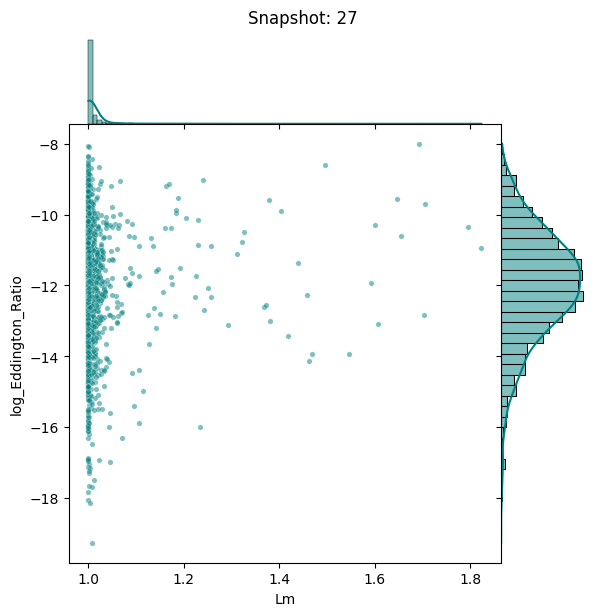

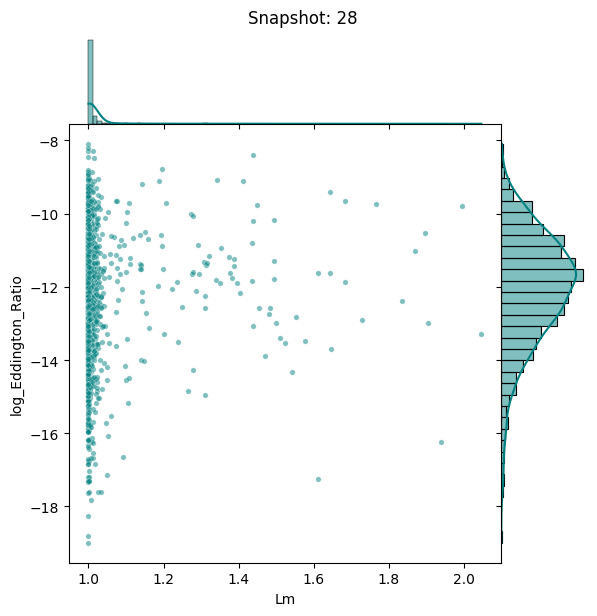

In [30]:
# Graficamos con seaborn para una visualización estática

def plot_snap(df, snap_id, var_x, var_y):
    # Filtramos con Polars
    data = df[(df["SnapNum"] == snap_id)]
    
    g = sns.JointGrid(data=data, x=var_x, y=var_y, space=0)
    g.plot_joint(sns.scatterplot, s=15, alpha=0.5, color="teal")
    g.plot_marginals(sns.histplot, kde=True, color="teal")
    g.fig.suptitle(f"Snapshot: {snap_id}", y=1.02)
    return g




df_final = (
    filtered_data
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
        (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Eddington_Ratio")
    plt.show()

### Construcción del grupo que sufrió un único major merger en su historia

In [31]:
# Si nos quedamos con las galaxias que sólo sufrieron un mayor merger en toda su historia. Da un total de 731 galaxias.

filtered_ids = (
    filtered_data
    .group_by("RootGalaxyID")
    .agg(
        (pl.col("Lm") > 1.25).sum().alias("n_major_mergers")
    )
    .filter(pl.col("n_major_mergers") == 1)
    .select("RootGalaxyID")
)

result_merger = filtered_data.join(
    filtered_ids,
    on="RootGalaxyID",
    how="inner"
)

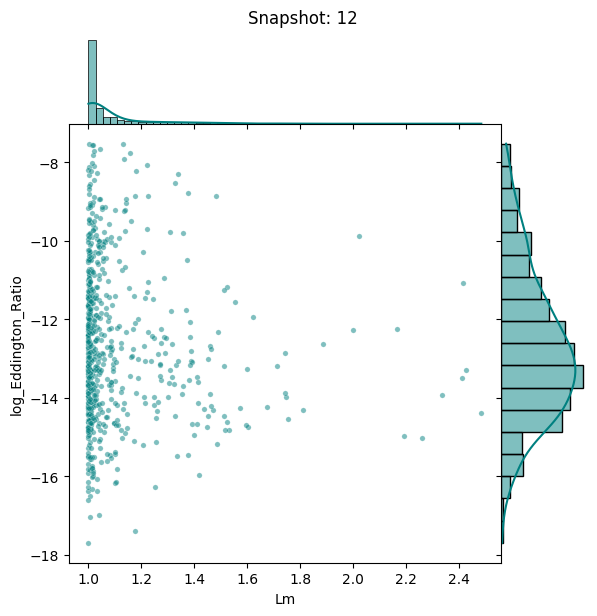

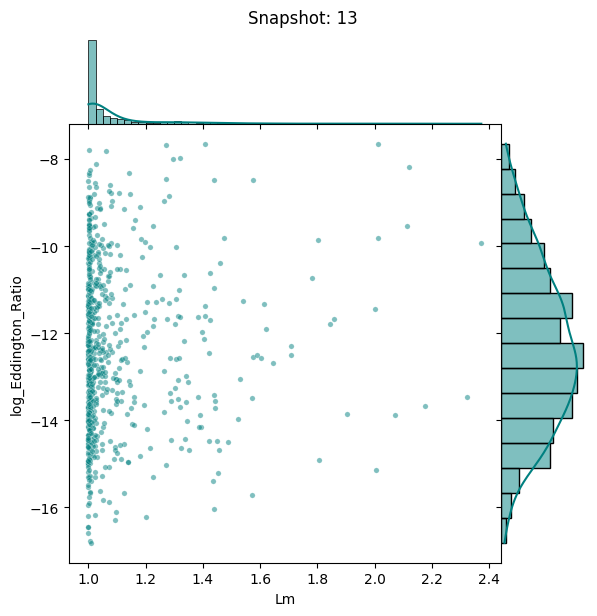

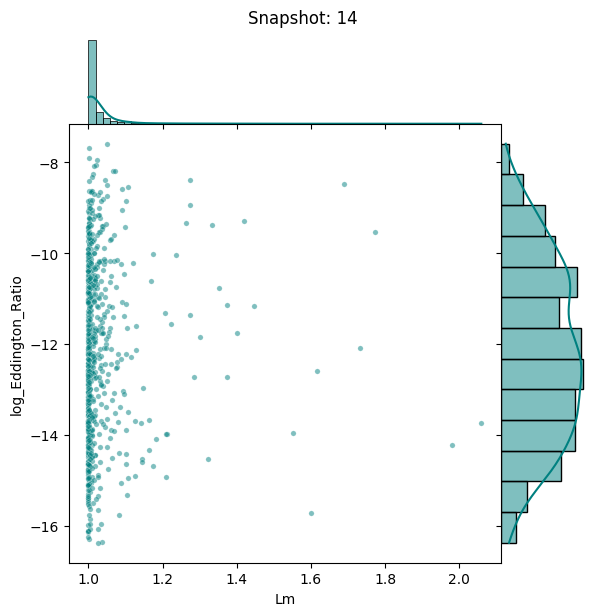

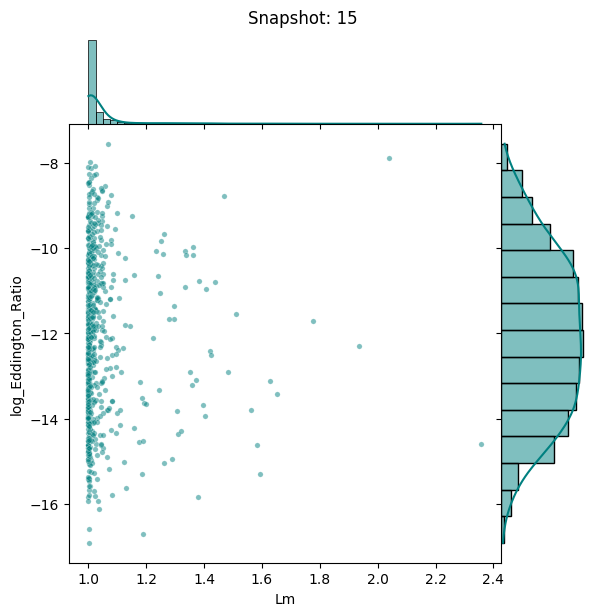

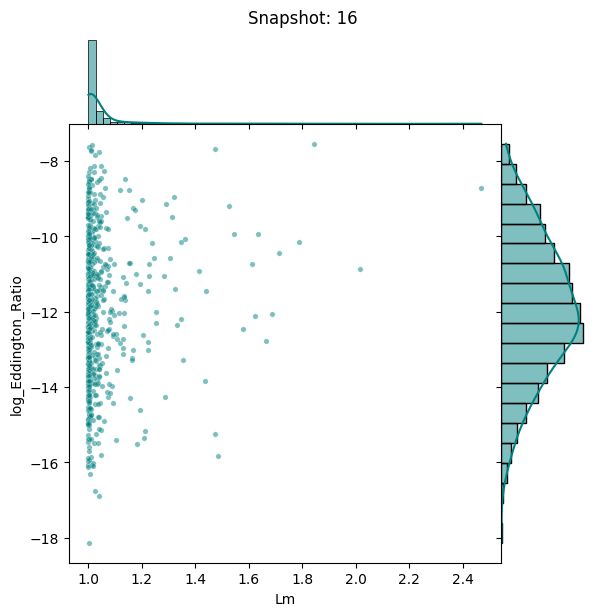

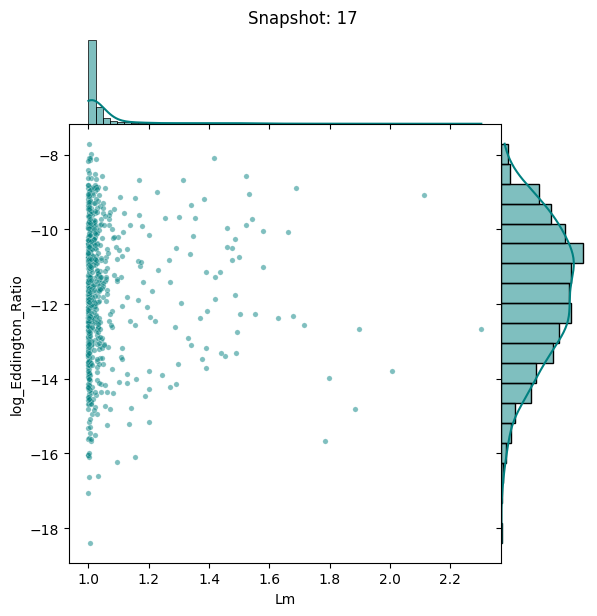

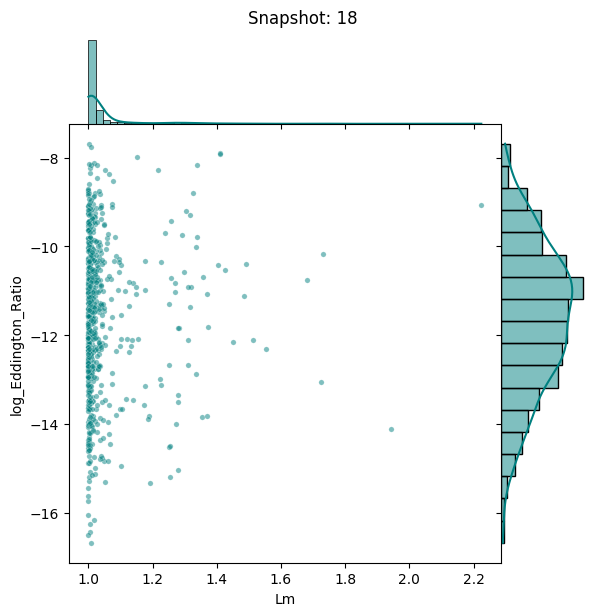

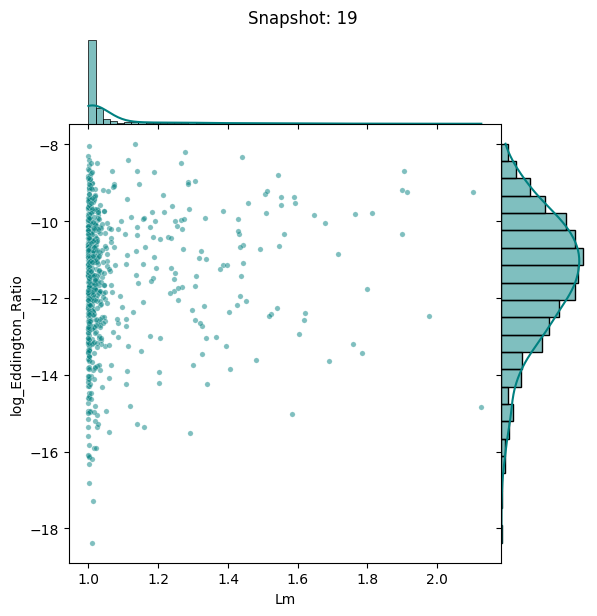

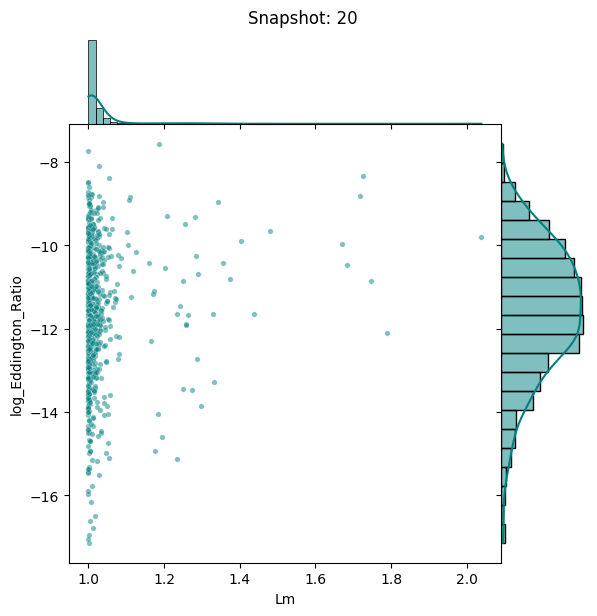

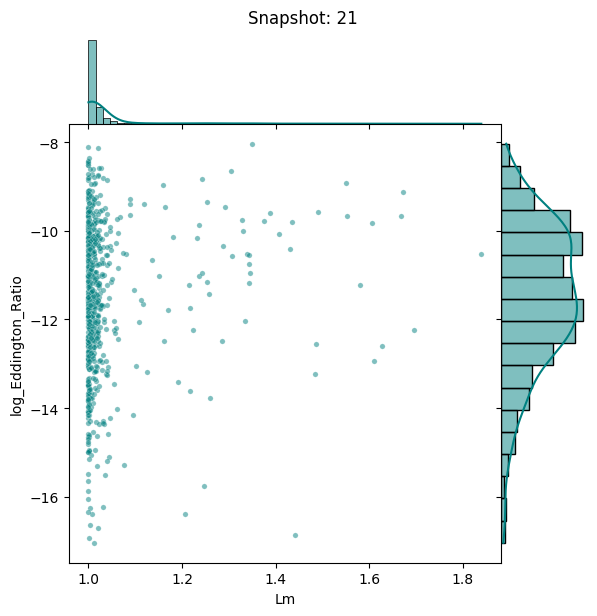

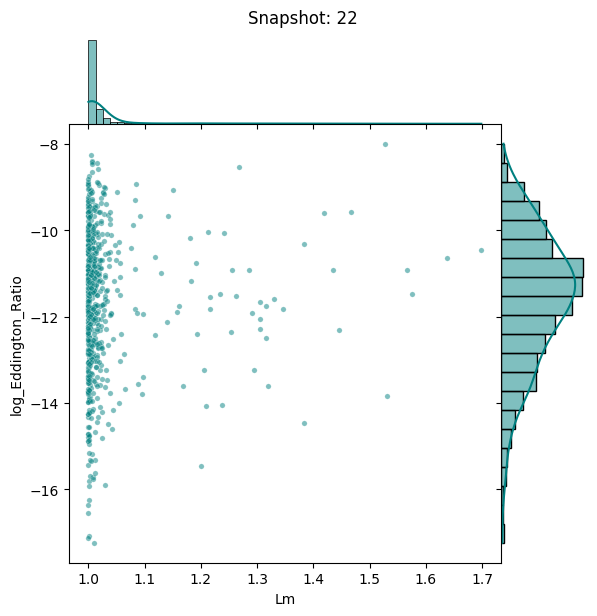

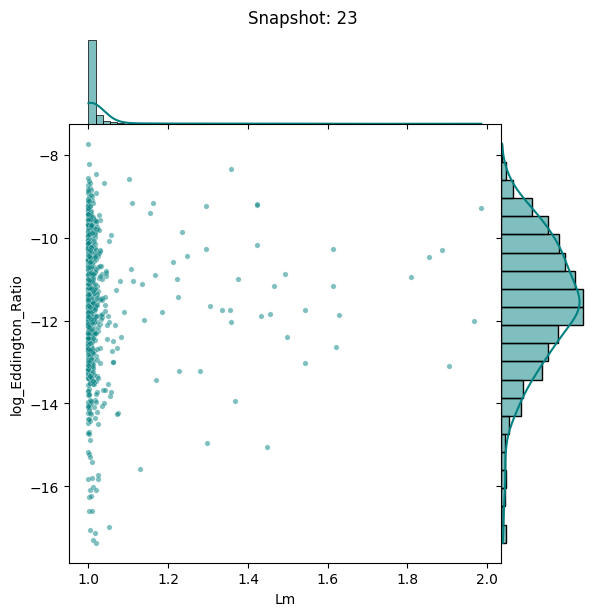

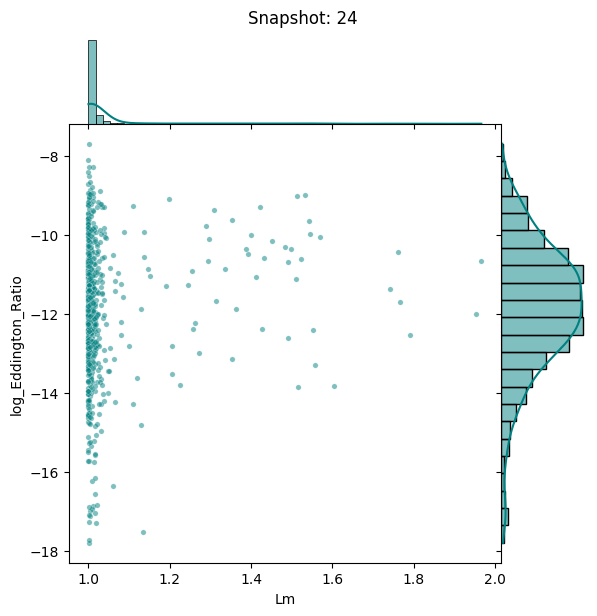

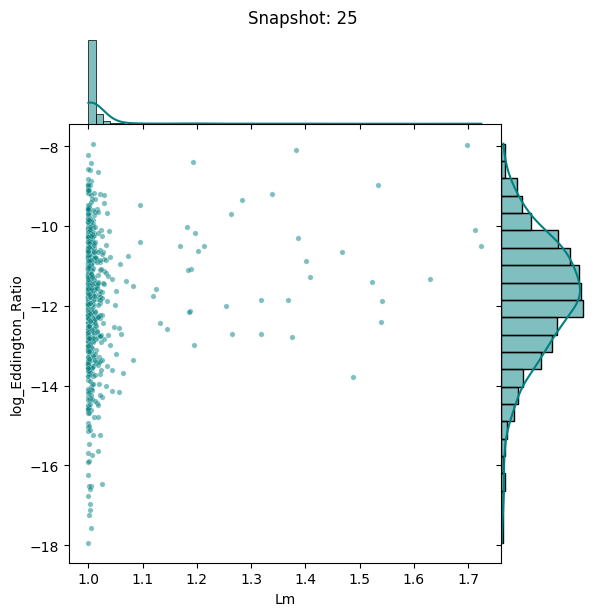

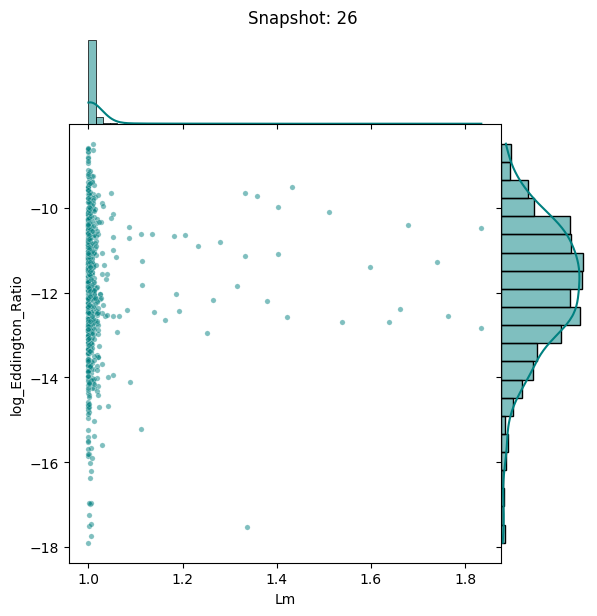

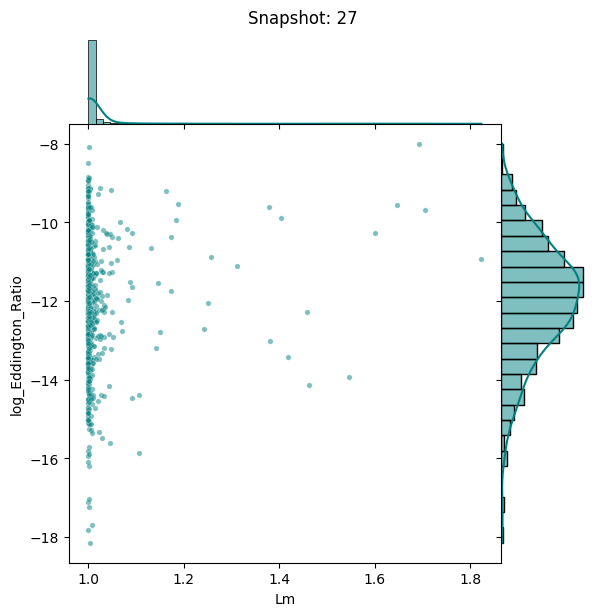

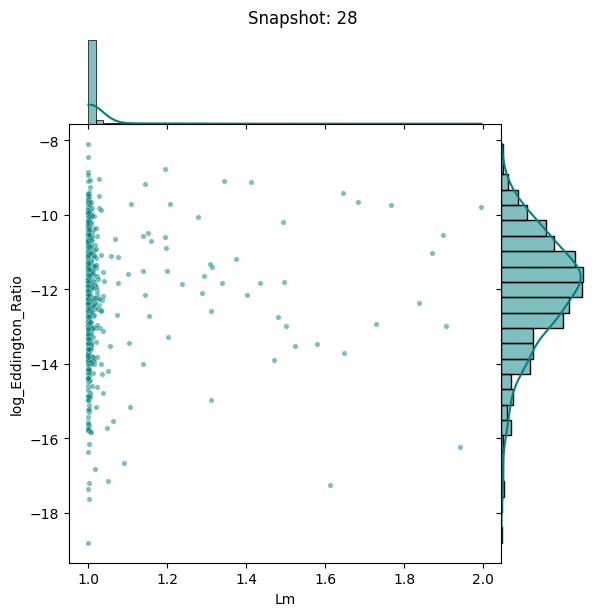

In [32]:
# Gráficos con las galaxias que sufrieron sólo un major merger en su historia
df_final = (
    result_merger
    .select([
        pl.col("SnapNum"),
        pl.col("Stars_Mass").log10().alias("log_Mstar"),
        pl.col("BlackHoleMass").log10().alias("log_MBH"),
        pl.col('12+log(O/H)'),
        pl.col('Lm'),
        (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio'),
    ])
    .to_pandas() # Aquí debería funcionar si tienes pyarrow
)

# Ejemplo: Mostrar 3 momentos clave en una fila
snaps_to_show = [12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28]
for s in snaps_to_show:
    plot_snap(df_final, s, "Lm", "log_Eddington_Ratio")
    plt.show()

Lo que queremos calcular ahora es el delta t, es decir separa los registros según antes (dt<0) o después (dt>0) del merger.
La idea es cuantificar cuanto cambian las magnitudes luego del evento.

In [33]:
# Creamos delta snap para cada galaxia, que es la diferencia entre el snap actual y el snap del major merger
# Primero obtenemos el snap del major merger para cada galaxia
major_merger_snaps = (
    result_merger
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("SnapNum").alias("Snap_Major_Merger"))
)

# Separamos tambien diferencia temporal
major_merger_time = (
    result_merger
    .filter(pl.col("Lm") > 1.25)
    .group_by("RootGalaxyID")
    .agg(pl.min("LookbackTime(Gyr)").alias("Time_Major_Merger"))
)

# Luego unimos esta información con el dataset original para calcular delta snap
result_with_delta = result_merger.join(major_merger_snaps, on="RootGalaxyID", how="left").with_columns(
    (pl.col("SnapNum") - pl.col("Snap_Major_Merger")).alias("Delta_Snap")
)

# Unimos también la información de tiempo para calcular delta tiempo
result_with_delta = result_with_delta.join(major_merger_time, on="RootGalaxyID", how="left").with_columns(
    (pl.col("LookbackTime(Gyr)") - pl.col("Time_Major_Merger")).alias("Delta_Time_Gyr")
)


In [34]:
result_with_delta

GalaxyID,SnapNum,Redshift,Stars_Mass,Stars_KineticEnergy,Stars_Spin_x,Stars_Spin_y,Stars_Spin_z,SF_Mass,SF_Oxygen,SF_Hydrogen,SF_MassWeightedTemperature,SF_KineticEnergy,SF_ThermalEnergy,SF_TotalEnergy,SF_Spin_x,SF_Spin_y,SF_Spin_z,BlackHoleMass,BlackHoleMassAccretionRate,SubHaloGalaxyID,RootGalaxyID,LookbackTime(Gyr),Lm,Log(Stars_Mass),Log(BlackHoleMass),Stars_Spin_Total,SF_Spin_Total,Total_Spin,12+log(O/H),Snap_Major_Merger,Delta_Snap,Time_Major_Merger,Delta_Time_Gyr
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64
8689661,12,3.0165045,3.9394144e8,1.4403e12,35.128006,-82.5278,-16.886503,5.6202176e8,0.002771,0.7426614,10638.657,1.1970e12,1.1670e11,-1.7340e13,33.266552,-1.250882,-68.648636,308156.72,2.3595e-10,8689661,8689645,11.68,1.005999,8.595432,5.488772,91.268661,76.294583,137.887429,8.36767,24,-12,4.12,7.56
8689660,13,2.4784133,7.279321e8,2.5715e12,-26.568527,-35.37504,13.256275,2.2182e9,0.002691,0.7423665,11189.634,9.3446e12,4.7469e11,-1.0583e14,-212.44557,-2.265337,-3.274268,308215.56,5.5702e-8,8689660,8689645,11.17,1.010501,8.862091,5.488855,46.184509,212.482876,242.165598,8.355224,24,-11,4.12,7.05
8689659,14,2.237037,1.0777e9,4.7914e12,-17.413115,-28.804552,-20.64489,2.7721e9,0.003175,0.740384,11147.517,1.1803e13,5.8834e11,-1.5415e14,-224.49707,-210.9354,177.73941,308517.6,9.4310e-9,8689659,8689645,10.87,1.006641,9.032508,5.48928,39.485824,355.645857,375.065955,8.428164,24,-10,4.12,6.75
8689658,15,2.0124102,1.5601e9,7.8809e12,-90.6459,-35.008163,-69.34195,3.6081e9,0.003697,0.738451,11750.763,1.5774e13,8.0621e11,-2.1217e14,-132.1504,-204.31976,-20.6284,309547.78,0.000001,8689658,8689645,10.54,1.0,9.193159,5.490728,119.375696,244.204471,339.13229,8.495363,24,-9,4.12,6.42
8689657,16,1.7369658,2.5613e9,1.6582e13,5.2884703,8.26441,-261.4432,5.5089e9,0.003984,0.7371053,11742.4795,3.4445e13,1.2367e12,-3.4529e14,-491.50455,-172.54085,-301.07648,494658.6,8.9021e-9,8689657,8689645,10.05,1.03792,9.408453,5.694306,261.627245,601.659467,761.459924,8.528717,24,-8,4.12,5.93
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
21986365,24,0.365669,8.0355e11,1.3398e17,-8157.2715,-4815.6025,-7921.742,1.5845e10,0.009007,0.7135603,14842.011,1.4543e15,4.3683e12,-1.8960e16,18130.81,-38427.527,-3099.3567,1.0961e9,0.00445,21986365,21986361,4.12,1.001543,11.905013,9.039858,12348.485821,42602.900307,45726.407422,8.897018,17,7,9.49,-5.37
21986364,25,0.270901,9.1478e11,2.1425e17,-3263.4863,-13905.607,-23574.283,1.4140e10,0.009128,0.7106501,15650.902,2.7811e15,4.1468e12,-1.6325e16,13426.726,-36767.79,-18871.074,1.1888e9,0.012013,21986364,21986361,3.24,1.000458,11.961315,9.075116,27563.799953,43454.168804,66878.194769,8.904597,17,8,9.49,-6.25
21986363,26,0.18271,1.0332e12,1.9705e17,-2159.21,-12064.919,-21040.172,1.0932e10,0.00931,0.711415,13835.004,1.2363e15,2.7834e12,-1.4122e16,12981.541,-47848.95,-39117.74,8.605493e8,0.000002,21986363,21986361,2.32,1.041736,12.014164,8.934776,24349.811007,63152.51385,85590.705821,8.912693,17,9,9.49,-7.17


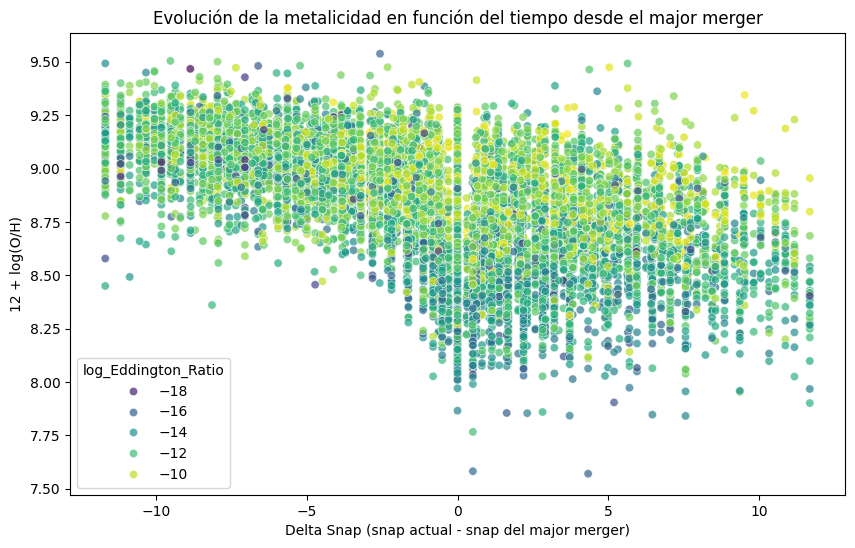

In [64]:
df =result_with_delta.filter( pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass') < 1e-9 ).with_columns(
    pl.col("Delta_Snap").alias("Delta_Snap"),
    pl.col("SnapNum").alias("SnapNum"),
    pl.col("Delta_Time_Gyr").alias("Delta_Time_Gyr"),
    pl.col("Lm").alias("Lm"),
    pl.col("12+log(O/H)").alias("12+log(O/H)"),
    (pl.col('BlackHoleMassAccretionRate')/pl.col('BlackHoleMass')).log10().alias('log_Eddington_Ratio')).to_pandas()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Delta_Time_Gyr", y="12+log(O/H)", hue="log_Eddington_Ratio", palette="viridis", alpha=0.7)
plt.title("Evolución de la metalicidad en función del tiempo desde el major merger")
plt.xlabel("Delta Snap (snap actual - snap del major merger)")
plt.ylabel("12 + log(O/H)")
plt.legend(title="log_Eddington_Ratio")
plt.show()